# 00: Data Extraction from Video
Bước đầu tiên trong quy trình: Trích xuất các khung hình (frames) từ video thô để tạo tập dữ liệu cho tiền xử lý và huấn luyện mô hình.

In [1]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np

# Cấu hình đường dẫn
VIDEO_DIR = '../data/raw_videos'
OUTPUT_DIR = '../data/raw_frames'

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Lấy danh sách video
videos = [f for f in os.listdir(VIDEO_DIR) if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))]
print(f"Tìm thấy {len(videos)} video.")
for i, v in enumerate(videos):
    print(f"[{i}]: {v}")

Tìm thấy 6 video.
[0]: 14286402_3840_2160_30fps.mp4
[1]: 5587732-uhd_3700_2082_30fps.mp4
[2]: cảnh-quay-trên-không-4k-ngay-phía-trên-một-chiếc-xe-điện-đậu-trong-không-gian-sạc-ô-tô-điện.mp4
[3]: một-chiếc-ô-tô-màu-đỏ-tấp-vào-chỗ-đậu-xe-và-lái-đi-bắn-từ-trên-không-bãi-đậu-xe-trống-dấu.mp4
[4]: người-phụ-nữ-cố-gắng-liên-tục-đỗ-xe-trong-bãi-đậu-xe-nhưng-không-thành-công (1).mp4
[5]: time-lapse-of-parking-lot-of-shopping-center-filled-with-different-cars-video.mp4


### Trích xuất video thứ 5 (Index 4)
Cài đặt đồng bộ với `extract_frames.py`: Lấy 1 ảnh mỗi 30 frames và chạy hết video.

In [2]:
TARGET_INDEX = 4 # Video thứ 5
if len(videos) > TARGET_INDEX:
    video_path = os.path.join(VIDEO_DIR, videos[TARGET_INDEX])
    print(f"🎬 Đang xử lý video: {videos[TARGET_INDEX]}")
    
    cap = cv2.VideoCapture(video_path)
    count = 0
    frame_id = 0
    extracted_paths = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        
        # Cứ mỗi 30 frame (khoảng 1 giây) lấy 1 ảnh (Đồng bộ với extract_frames.py)
        if count % 30 == 0:
            file_name = f'frame_{frame_id:04d}.jpg'
            save_path = os.path.join(OUTPUT_DIR, file_name)
            cv2.imwrite(save_path, frame)
            extracted_paths.append(save_path)
            frame_id += 1
        count += 1

    cap.release()
    print(f"✅ Đã trích xuất xong toàn bộ video. Tổng cộng: {frame_id} ảnh.")
else:
    print("❌ LỖI: Không tìm thấy video ở index này!")

🎬 Đang xử lý video: người-phụ-nữ-cố-gắng-liên-tục-đỗ-xe-trong-bãi-đậu-xe-nhưng-không-thành-công (1).mp4
✅ Đã trích xuất xong toàn bộ video. Tổng cộng: 33 ảnh.


### Kiểm tra trực quan kết quả

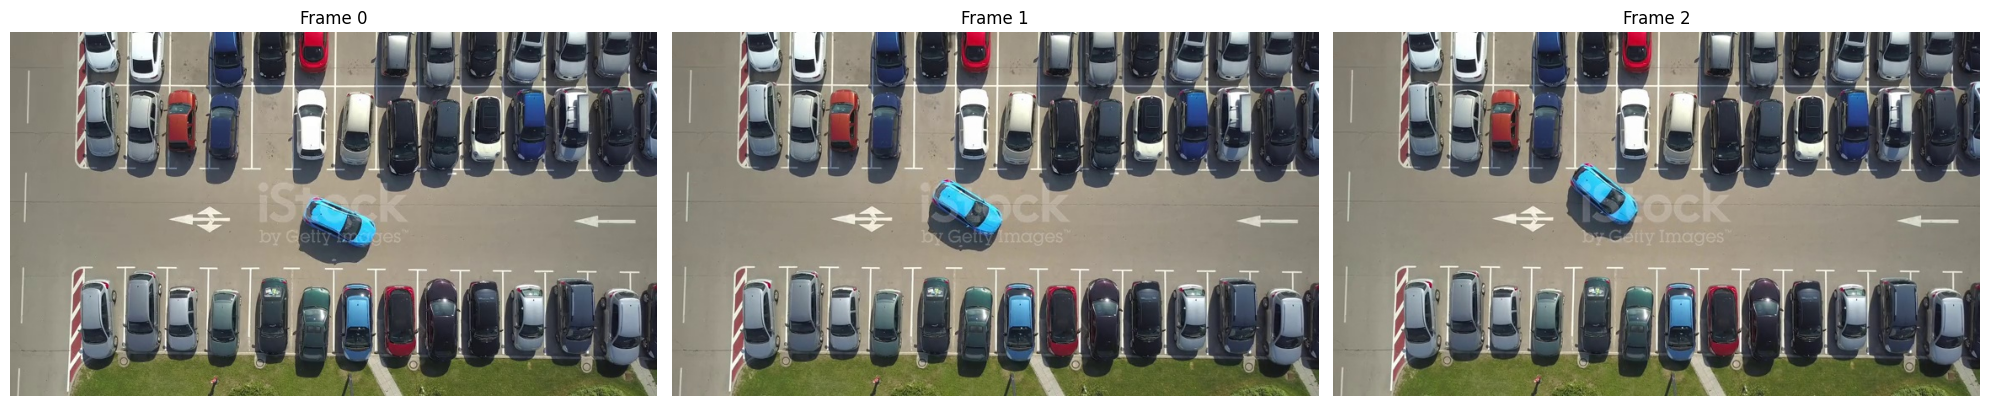

In [3]:
if 'extracted_paths' in locals() and len(extracted_paths) > 0:
    # Hiển thị 3 ảnh đầu tiên
    num_show = min(3, len(extracted_paths))
    fig, axes = plt.subplots(1, num_show, figsize=(20, 10))
    if num_show == 1: axes = [axes]
    
    for i in range(num_show):
        img = cv2.imread(extracted_paths[i])
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
        axes[i].set_title(f"Frame {i}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Chưa có ảnh nào được trích xuất.")